# Bank Marketing Term Deposit Prediction

**Dataset:** UCI Bank Marketing (Moro et al., 2014)
**Task:** Predict if a client will subscribe to a term deposit (yes/no)

---

### What I am doing in this notebook

1. Look at the data and make some plots to understand it
2. Clean the data and handle the tricky parts (the `pdays = -1` thing, the `duration` leakage)
3. Train some baseline models: Logistic Regression, Random Forest, XGBoost
4. Build a deep MLP in PyTorch with embeddings, residual blocks, batch norm, dropout, and focal loss
5. Build an FT-Transformer (an actual transformer for tabular data)
6. Evaluate everything properly — not with accuracy, because the data is imbalanced
7. Run an ablation to see which tricks actually help

### Why I made these choices

Only about 12% of the clients say yes, so accuracy is a bad metric here. A model that always says "no" gets 88% accuracy and is useless. So I use AUC-PR, F1, and MCC instead.

The `duration` feature is the length of the call. You only know it after the call is over, so using it to decide who to call doesn't make sense. I drop it from the main models and only use it in one ablation to show how much it inflates the numbers.

## 1. Setup

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, matthews_corrcoef,
    precision_score, recall_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

import xgboost as xgb

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
PALETTE = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b', '#8b5cf6', '#ec4899']
sns.set_palette(PALETTE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

PyTorch: 2.7.1+cu128
Device:  cuda
GPU:     NVIDIA GeForce RTX 5070 Ti


## 2. Load the dataset

`bank-full.csv` has 45,211 rows. There is also a smaller `bank.csv` which is just a 10% random sample.

In [2]:
DATA_PATH = 'bank-full.csv'  # adjust path as needed
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print('Numerical features:', df.select_dtypes(include=np.number).columns.tolist())
print('Categorical features:', df.select_dtypes(include='object').columns.tolist())
print(f'\nTarget distribution:\n{df.y.value_counts()}')
print(f'\nPositive rate: {(df.y == "yes").mean():.4f}')

Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Positive rate: 0.1170


## 3. Looking at the data

Before building any models, I want to understand what is in the data. The plots below cover:

- The class imbalance
- How the numerical features look
- How the categorical features relate to the target
- The duration leakage problem
- The `pdays = -1` issue
- Correlations

These plots are what I used to decide how to preprocess everything in Section 4.

### 3.1 The class imbalance

Only 11.7% of clients subscribe. This is the main thing that makes the problem hard. If I just predict "no" for everyone I get 88.3% accuracy and zero useful predictions, which is why I avoid accuracy as a metric.

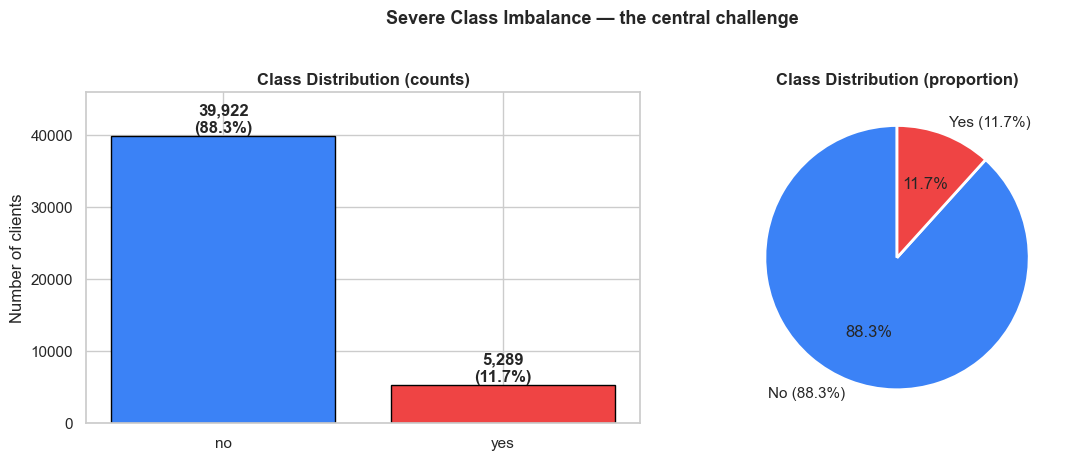

Imbalance ratio: 1 positive per 7.55 negatives
Naive "all-no" accuracy baseline: 88.30%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts = df['y'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#3b82f6', '#ef4444'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (counts)', fontweight='bold')
axes[0].set_ylabel('Number of clients')
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values, labels=['No (88.3%)', 'Yes (11.7%)'],
            colors=['#3b82f6', '#ef4444'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (proportion)', fontweight='bold')

plt.suptitle('Severe Class Imbalance — the central challenge',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Imbalance ratio: 1 positive per {(df.y=="no").sum() / (df.y=="yes").sum():.2f} negatives')
print(f'Naive "all-no" accuracy baseline: {(df.y=="no").mean()*100:.2f}%')

### 3.2 Numerical features

Some features (`balance`, `duration`, `campaign`, `previous`) are very skewed with extreme values. This is why I use RobustScaler later — it uses the median and IQR so it does not get thrown off by outliers.

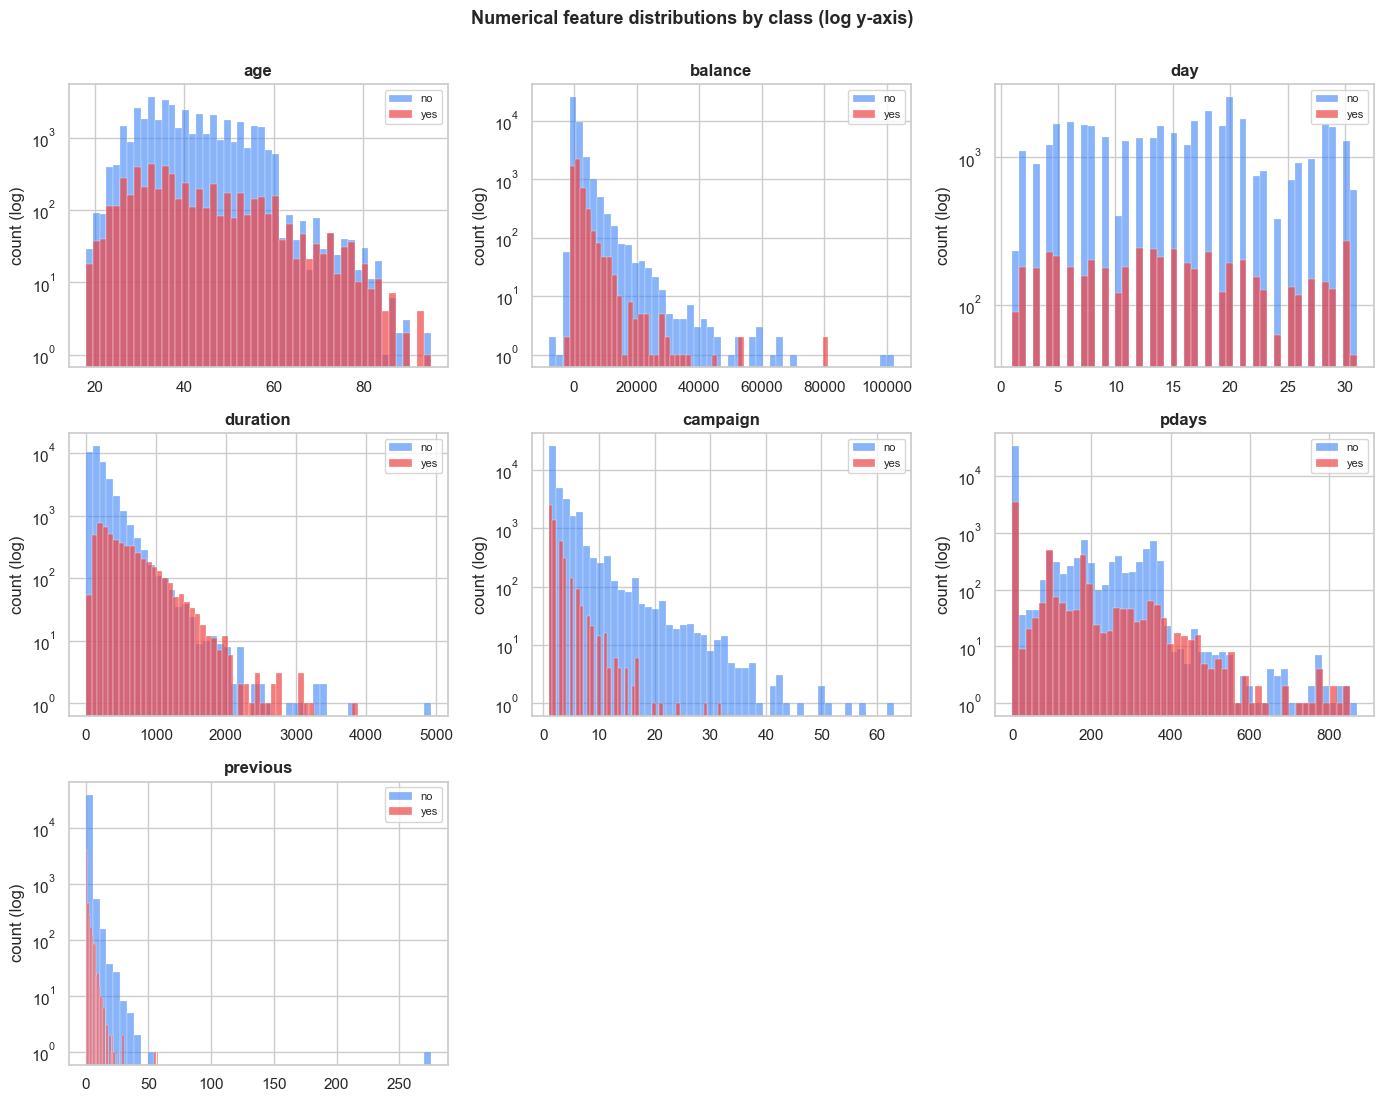

In [5]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[df.y == 'no'][col], bins=50, alpha=0.6,
            color='#3b82f6', label='no', edgecolor='white', linewidth=0.3)
    ax.hist(df[df.y == 'yes'][col], bins=50, alpha=0.7,
            color='#ef4444', label='yes', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.set_ylabel('count (log)')
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Numerical feature distributions by class (log y-axis)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.3 Outliers

Look at `balance`. Most people have small balances but some have over €100,000. StandardScaler would be ruined by these. RobustScaler ignores the extremes.

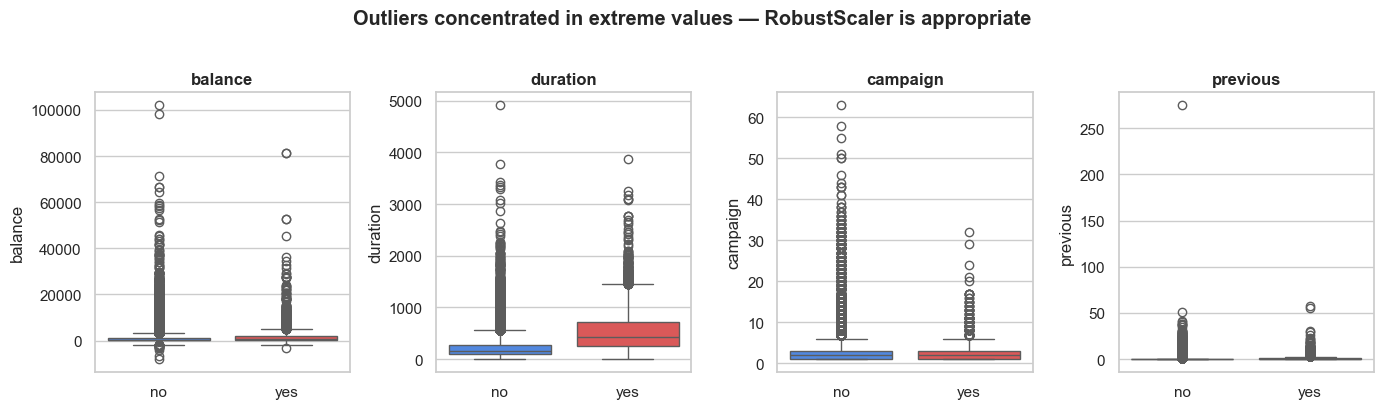

balance: 99th = €13,165, max = €102,127
campaign: 99th = 16, max = 63


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, ['balance', 'duration', 'campaign', 'previous']):
    sns.boxplot(data=df, x='y', y=col, ax=ax, palette=['#3b82f6', '#ef4444'])
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Outliers concentrated in extreme values — RobustScaler is appropriate',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"balance: 99th = €{df.balance.quantile(0.99):,.0f}, max = €{df.balance.max():,.0f}")
print(f"campaign: 99th = {df.campaign.quantile(0.99):.0f}, max = {df.campaign.max()}")

### 3.4 The `pdays = -1` sentinel

Fraction with pdays == -1 (never contacted): 0.8174


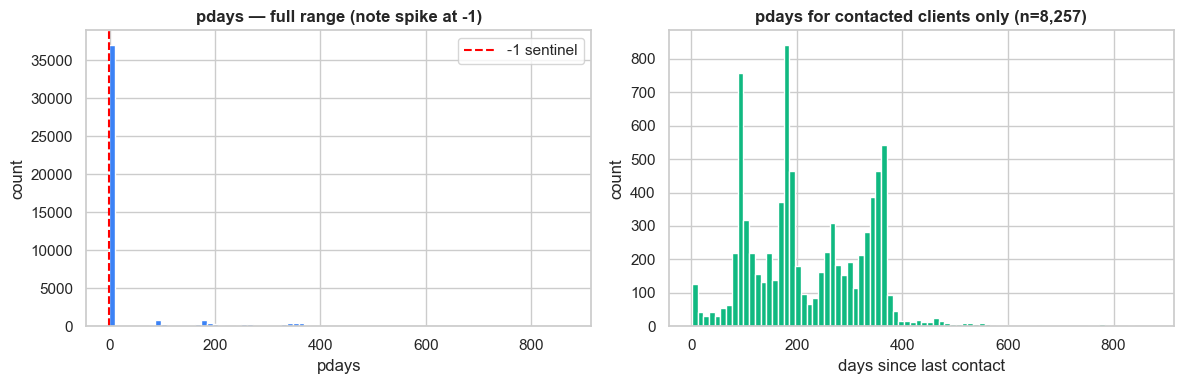

In [7]:
never = (df.pdays == -1).mean()
print(f'Fraction with pdays == -1 (never contacted): {never:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df.pdays, bins=80, color='#3b82f6', edgecolor='white')
axes[0].axvline(-1, color='red', linestyle='--', label='-1 sentinel')
axes[0].set_title('pdays — full range (note spike at -1)', fontweight='bold')
axes[0].set_xlabel('pdays'); axes[0].set_ylabel('count'); axes[0].legend()

contacted = df[df.pdays != -1]
axes[1].hist(contacted.pdays, bins=80, color='#10b981', edgecolor='white')
axes[1].set_title(f'pdays for contacted clients only (n={len(contacted):,})', fontweight='bold')
axes[1].set_xlabel('days since last contact'); axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()

### 3.5 Categorical features

For each category, I compute the fraction of clients who said yes. The red line is the overall baseline (11.7%). Green bars are above the baseline, red bars are below.

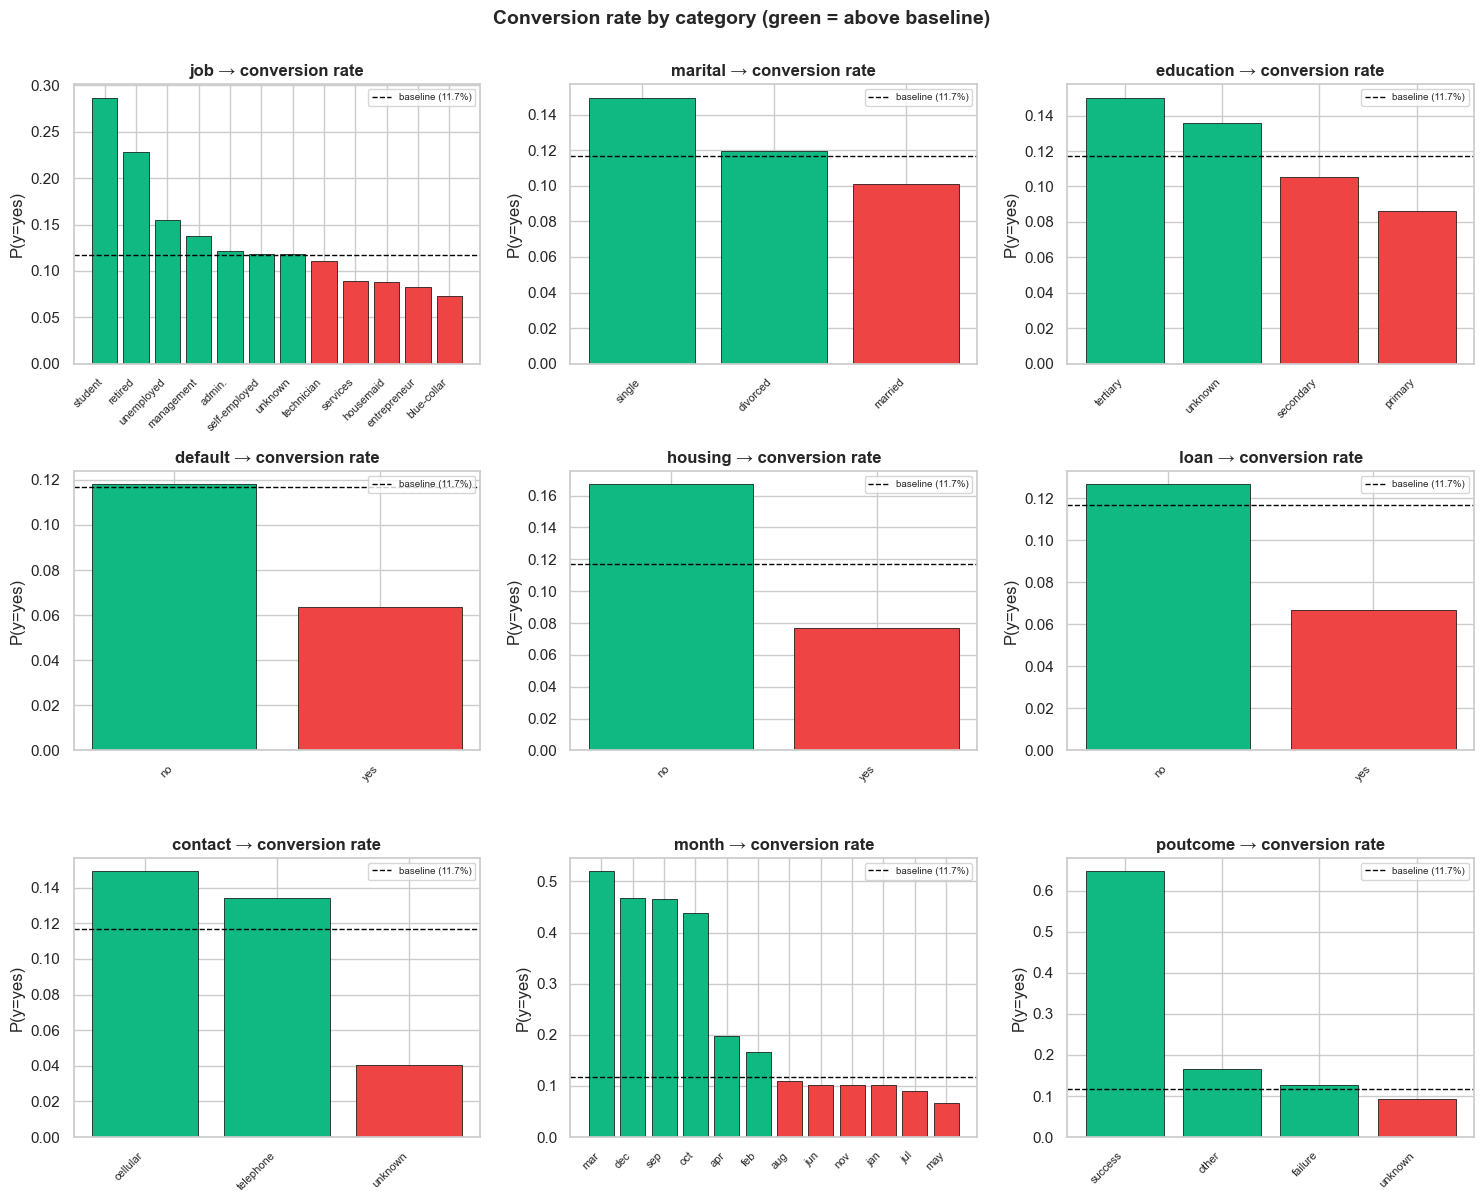

In [8]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome']
baseline = (df.y == 'yes').mean()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ax = axes[i]
    rates = df.groupby(col).apply(lambda g: (g.y == 'yes').mean()).sort_values(ascending=False)
    colors = ['#10b981' if r > baseline else '#ef4444' for r in rates.values]
    ax.bar(range(len(rates)), rates.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45, ha='right', fontsize=8)
    ax.axhline(baseline, color='black', linestyle='--', linewidth=1, label=f'baseline ({baseline:.1%})')
    ax.set_title(f'{col} → conversion rate', fontweight='bold')
    ax.set_ylabel('P(y=yes)')
    ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Conversion rate by category (green = above baseline)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**What I noticed:**

- `poutcome = success` is by far the strongest signal — clients who said yes in a previous campaign say yes about 65% of the time
- Students and retired people convert about twice as much as the average
- March, September, October, and December are the best months. May (the most-called month) is below average
- Cellular contact works better than telephone or unknown
- Clients with no housing loan and no personal loan convert more

### 3.6 The duration problem

This is the most important thing to understand about this dataset. `duration` is how long the phone call lasted. You only know this *after* the call is finished, but by then you already know if the client said yes or no. Using it to predict the answer is cheating. The UCI page literally tells you not to use it for real prediction.

Including it pushes AUC up by about 14 points. I drop it from the main models and only use it in one ablation to show what happens.

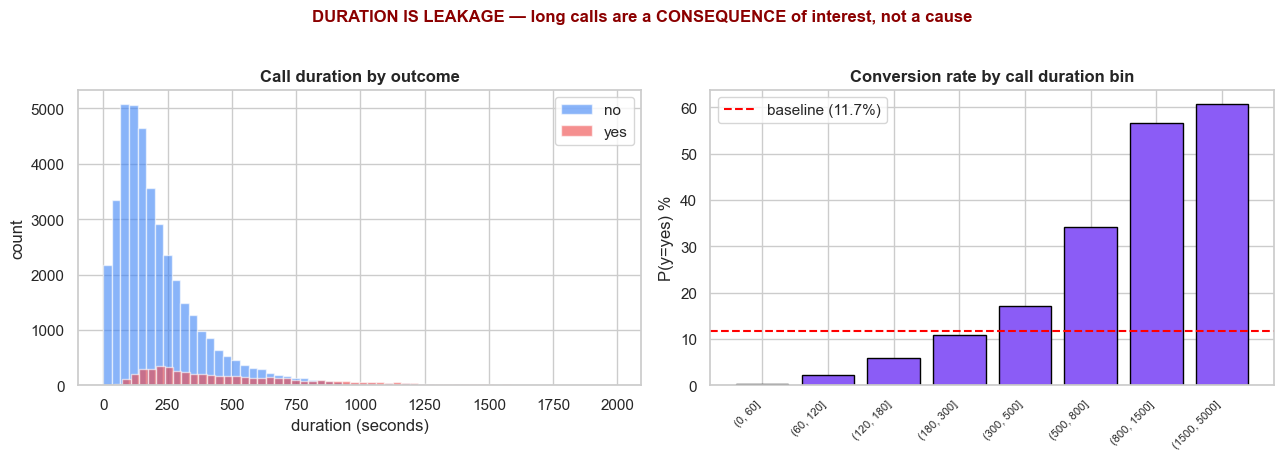

UCI repository: "duration is not known before a call is performed... should be
discarded if the intention is to have a realistic predictive model."


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label, color in [('no', '#3b82f6'), ('yes', '#ef4444')]:
    sub = df[df.y == label].duration
    axes[0].hist(sub[sub < 2000], bins=60, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Call duration by outcome', fontweight='bold')
axes[0].set_xlabel('duration (seconds)'); axes[0].set_ylabel('count')
axes[0].legend()

df['_dur_bin'] = pd.cut(df.duration, bins=[0, 60, 120, 180, 300, 500, 800, 1500, 5000])
rates = df.groupby('_dur_bin').apply(lambda g: (g.y == 'yes').mean())
axes[1].bar(range(len(rates)), rates.values * 100, color='#8b5cf6', edgecolor='black')
axes[1].set_xticks(range(len(rates)))
axes[1].set_xticklabels([str(b) for b in rates.index], rotation=45, ha='right', fontsize=8)
axes[1].axhline(baseline*100, color='red', linestyle='--', label=f'baseline ({baseline*100:.1f}%)')
axes[1].set_title('Conversion rate by call duration bin', fontweight='bold')
axes[1].set_ylabel('P(y=yes) %')
axes[1].legend()

plt.suptitle('DURATION IS LEAKAGE — long calls are a CONSEQUENCE of interest, not a cause',
             fontsize=12, fontweight='bold', color='darkred', y=1.02)
plt.tight_layout()
plt.show()
df.drop(columns=['_dur_bin'], inplace=True)
print('UCI repository: "duration is not known before a call is performed... should be')
print('discarded if the intention is to have a realistic predictive model."')

### 3.7 Correlation heatmap

Most numerical features are not strongly correlated with each other, so I do not need to worry about multicollinearity.

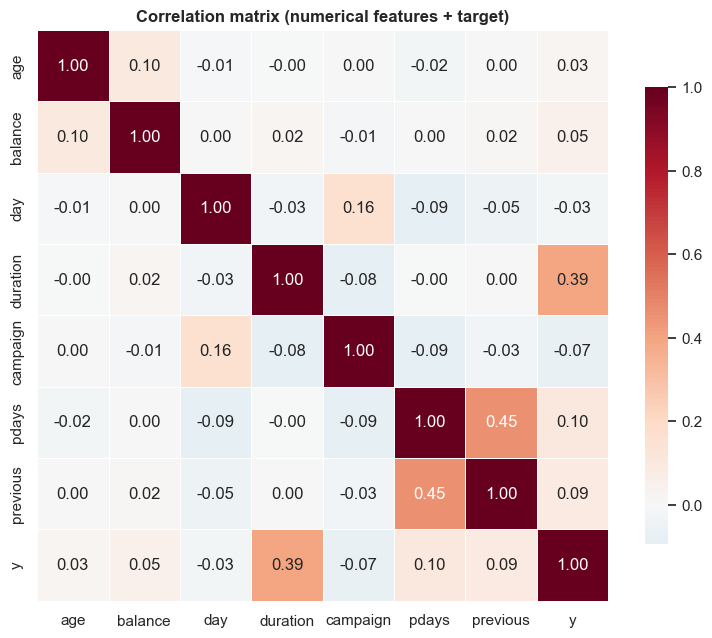

In [10]:
num_with_target = df[num_cols].copy()
num_with_target['y'] = (df.y == 'yes').astype(int)
corr = num_with_target.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation matrix (numerical features + target)', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 EDA Summary

| Finding | Implication |
|---|---|
| 11.7% positive class | Use AUC-PR, MCC, F1; never accuracy. Use focal loss. |
| `balance` has extreme outliers | Use RobustScaler, not StandardScaler |
| `pdays = -1` for ~82% of clients | Create `was_contacted_before` flag, zero out -1 |
| `duration` strongly correlates but is leakage | **Drop from primary analysis**; ablate separately |
| `poutcome = success` is the strongest predictor | Embeddings should capture this easily |
| Strong seasonal effect (month) | Use embeddings, not one-hot |
| No severe multicollinearity | No need for PCA / feature pruning |

## 4. Preprocessing

Based on what I saw in the EDA:

1. Drop `duration` (leakage). I add it back only for one ablation.
2. Make `was_contacted_before` binary, set `pdays = -1` to 0.
3. RobustScaler on numerical features, fit only on the training set.
4. Ordinal encode the categoricals so I can feed them to embeddings. One-hot for the baselines.
5. Stratified 60/20/20 split so all three sets have the same class ratio.

In [11]:
def preprocess(df, drop_duration=True):
    df = df.copy()
    df['y'] = (df.y == 'yes').astype(np.int64)
    if drop_duration and 'duration' in df.columns:
        df = df.drop(columns=['duration'])
    df['was_contacted_before'] = (df.pdays != -1).astype(np.int64)
    df.loc[df.pdays == -1, 'pdays'] = 0
    return df

CAT_COLS = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome']
NUM_COLS_BASE = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous',
                 'was_contacted_before']

df_clean = preprocess(df, drop_duration=True)
print(f'After preprocessing: {df_clean.shape}')

After preprocessing: (45211, 17)


In [12]:
train_df, temp_df = train_test_split(df_clean, test_size=0.4, stratify=df_clean.y,
                                      random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df.y,
                                    random_state=SEED)
print(f'Train: {len(train_df):,}  ({(train_df.y==1).mean():.4f} positive)')
print(f'Val:   {len(val_df):,}  ({(val_df.y==1).mean():.4f} positive)')
print(f'Test:  {len(test_df):,}  ({(test_df.y==1).mean():.4f} positive)')

Train: 27,126  (0.1170 positive)
Val:   9,042  (0.1170 positive)
Test:  9,043  (0.1170 positive)


In [13]:
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ord_enc.fit(train_df[CAT_COLS])
scaler = RobustScaler()
scaler.fit(train_df[NUM_COLS_BASE])

cardinalities = [len(c) for c in ord_enc.categories_]
embed_dims = [min(50, (c + 1) // 2) for c in cardinalities]

print('Categorical cardinalities and embedding dims:')
print(f"{'Feature':<20}{'Card':<8}{'Embed':<8}")
print('-' * 36)
for n, c, d in zip(CAT_COLS, cardinalities, embed_dims):
    print(f'{n:<20}{c:<8}{d:<8}')
print('-' * 36)
print(f'Total: {sum(embed_dims)} embed + {len(NUM_COLS_BASE)} num = {sum(embed_dims)+len(NUM_COLS_BASE)} input')

Categorical cardinalities and embedding dims:
Feature             Card    Embed   
------------------------------------
job                 12      6       
marital             3       2       
education           4       2       
default             2       1       
housing             2       1       
loan                2       1       
contact             3       2       
month               12      6       
poutcome            4       2       
------------------------------------
Total: 23 embed + 7 num = 30 input


In [14]:
def transform(d):
    cat = ord_enc.transform(d[CAT_COLS]).astype(np.int64)
    cat = np.where(cat < 0, 0, cat)
    num = scaler.transform(d[NUM_COLS_BASE]).astype(np.float32)
    y = d.y.values.astype(np.float32)
    return cat, num, y

X_cat_tr, X_num_tr, y_tr = transform(train_df)
X_cat_va, X_num_va, y_va = transform(val_df)
X_cat_te, X_num_te, y_te = transform(test_df)
print(f'Train tensors: cat {X_cat_tr.shape}, num {X_num_tr.shape}')

Train tensors: cat (27126, 9), num (27126, 7)


## 5. Baseline models

I compare the deep models against three baselines, so I know if the deep stuff is actually helping. Tree models get label-encoded features, logistic regression gets one-hot.

In [15]:
def one_hot_version(d):
    d_oh = pd.get_dummies(d[CAT_COLS + NUM_COLS_BASE], columns=CAT_COLS, drop_first=False)
    return d_oh.astype(np.float32)

X_oh_tr = one_hot_version(train_df)
X_oh_va = one_hot_version(val_df).reindex(columns=X_oh_tr.columns, fill_value=0)
X_oh_te = one_hot_version(test_df).reindex(columns=X_oh_tr.columns, fill_value=0)

oh_scaler = RobustScaler()
X_oh_tr[NUM_COLS_BASE] = oh_scaler.fit_transform(X_oh_tr[NUM_COLS_BASE])
X_oh_va[NUM_COLS_BASE] = oh_scaler.transform(X_oh_va[NUM_COLS_BASE])
X_oh_te[NUM_COLS_BASE] = oh_scaler.transform(X_oh_te[NUM_COLS_BASE])
print(f'One-hot shape: {X_oh_tr.shape}')

One-hot shape: (27126, 51)


In [16]:
def find_threshold_on_val(y_val, p_val):
    precs, recs, ths = precision_recall_curve(y_val, p_val)
    f1s = 2 * precs * recs / (precs + recs + 1e-12)
    best_idx = np.nanargmax(f1s[:-1])
    return ths[best_idx]

def eval_model(name, p_val, p_test, results):
    thr = find_threshold_on_val(y_va, p_val)
    y_pred = (p_test >= thr).astype(int)
    results.append({
        'model': name,
        'AUC-ROC': roc_auc_score(y_te, p_test),
        'AUC-PR': average_precision_score(y_te, p_test),
        'F1': f1_score(y_te, y_pred),
        'MCC': matthews_corrcoef(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred),
        'Threshold': thr,
    })
    r = results[-1]
    print(f"{name:<22} AUC-ROC={r['AUC-ROC']:.4f}  AUC-PR={r['AUC-PR']:.4f}  F1={r['F1']:.4f}  MCC={r['MCC']:.4f}")

results = []

In [17]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                        random_state=SEED, n_jobs=-1)
lr.fit(X_oh_tr, y_tr)
eval_model('Logistic Regression',
           lr.predict_proba(X_oh_va)[:, 1],
           lr.predict_proba(X_oh_te)[:, 1], results)

Logistic Regression    AUC-ROC=0.7767  AUC-PR=0.4369  F1=0.4462  MCC=0.3677


In [18]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
                            class_weight='balanced_subsample',
                            n_jobs=-1, random_state=SEED)
rf.fit(X_oh_tr, y_tr)
eval_model('Random Forest',
           rf.predict_proba(X_oh_va)[:, 1],
           rf.predict_proba(X_oh_te)[:, 1], results)

Random Forest          AUC-ROC=0.8023  AUC-PR=0.4819  F1=0.4967  MCC=0.4305


In [19]:
# XGBoost
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=neg/pos, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1, tree_method='hist'
)
xgb_clf.fit(X_oh_tr, y_tr, eval_set=[(X_oh_va, y_va)], verbose=False)
eval_model('XGBoost',
           xgb_clf.predict_proba(X_oh_va)[:, 1],
           xgb_clf.predict_proba(X_oh_te)[:, 1], results)

XGBoost                AUC-ROC=0.7969  AUC-PR=0.4742  F1=0.4962  MCC=0.4291


## 6. Building the deep MLP in PyTorch

Now the deep model. The architecture:

```
Categorical features ──> Embeddings ──┐
                                       ├──> concat ──> Linear ──> 4 Residual Blocks ──> Linear ──> logit
Numerical features ───────────────────┘
```

What is in it:

1. **Embeddings** for the categorical features instead of one-hot. Each category gets a small learned vector.
2. **Residual blocks** so I can have a deeper network without the gradients dying.
3. **Batch norm before dropout** in each block (this ordering matters — putting dropout before BN causes problems).
4. **Focal loss** instead of plain BCE for the imbalance.
5. **Output bias starts at log(0.117/0.883) ≈ -2.02** so the model starts by predicting the right base rate. Without this, focal loss can blow up early in training.
6. **AdamW optimizer**, cosine annealing scheduler, gradient clipping, early stopping on val AUC-PR.
7. **Kaiming init** for the linear layers.

In [20]:
class BankDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.from_numpy(X_cat).long()
        self.X_num = torch.from_numpy(X_num).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return self.X_cat[i], self.X_num[i], self.y[i]

train_ds = BankDataset(X_cat_tr, X_num_tr, y_tr)
val_ds   = BankDataset(X_cat_va, X_num_va, y_va)
test_ds  = BankDataset(X_cat_te, X_num_te, y_te)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)
print(f'Batches per epoch: {len(train_loader)}')

Batches per epoch: 106


In [21]:
class BinaryFocalLoss(nn.Module):
    """
    Focal loss for binary classification (Lin et al. 2017).
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    Operates on logits for numerical stability.
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - p_t) ** self.gamma * bce
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum': return loss.sum()
        return loss

In [22]:
class ResidualBlock(nn.Module):
    """ResNet-style block: BN -> Linear -> ReLU -> Dropout -> Linear -> Dropout, with skip."""
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.bn = nn.BatchNorm1d(dim)
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        h = self.bn(x)
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.dropout(h)
        return x + h


class TabularResNet(nn.Module):
    """
    Modern MLP for tabular data with:
    - Learned categorical embeddings
    - N residual blocks
    - BatchNorm + Dropout regularization
    - Output bias initialized to class log-prior
    """
    def __init__(self, cardinalities, embed_dims, num_features,
                 hidden_dim=256, n_blocks=4, dropout=0.2,
                 use_embeddings=True, use_residual=True, use_bn=True,
                 prior=0.117):
        super().__init__()
        self.use_embeddings = use_embeddings
        self.use_residual = use_residual
        self.use_bn = use_bn
        self.cardinalities = cardinalities

        if use_embeddings:
            self.embeddings = nn.ModuleList([
                nn.Embedding(card + 1, dim) for card, dim in zip(cardinalities, embed_dims)
            ])
            for emb in self.embeddings:
                nn.init.normal_(emb.weight, mean=0.0, std=0.01)
            cat_dim = sum(embed_dims)
        else:
            self.embeddings = None
            cat_dim = sum(cardinalities)

        self.input_proj = nn.Linear(cat_dim + num_features, hidden_dim)

        if use_residual:
            self.blocks = nn.ModuleList([
                ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)
            ])
        else:
            layers = []
            for _ in range(n_blocks):
                if use_bn: layers.append(nn.BatchNorm1d(hidden_dim))
                layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
            self.blocks = nn.Sequential(*layers)

        self.head_bn = nn.BatchNorm1d(hidden_dim) if use_bn else nn.Identity()
        self.head_dropout = nn.Dropout(0.1)
        self.head = nn.Linear(hidden_dim, 1)

        with torch.no_grad():
            self.head.bias.fill_(float(np.log(prior / (1 - prior))))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None and m is not self.head:
                    nn.init.zeros_(m.bias)

    def forward(self, x_cat, x_num):
        if self.use_embeddings:
            x_cat_c = torch.stack([
                torch.clamp(x_cat[:, i], 0, c - 1) for i, c in enumerate(self.cardinalities)
            ], dim=1)
            embs = [emb(x_cat_c[:, i]) for i, emb in enumerate(self.embeddings)]
            cat_repr = torch.cat(embs, dim=1)
        else:
            ohs = []
            for i, c in enumerate(self.cardinalities):
                oh = F.one_hot(torch.clamp(x_cat[:, i], 0, c - 1), num_classes=c).float()
                ohs.append(oh)
            cat_repr = torch.cat(ohs, dim=1)

        x = torch.cat([cat_repr, x_num], dim=1)
        x = self.input_proj(x)
        if self.use_residual:
            for block in self.blocks: x = block(x)
        else:
            x = self.blocks(x)
        x = self.head_bn(x)
        x = F.relu(x)
        x = self.head_dropout(x)
        return self.head(x).squeeze(-1)

In [23]:
def train_model(model, train_loader, val_loader, criterion,
                lr=1e-3, weight_decay=1e-5, epochs=100, patience=15,
                verbose=True):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=15, T_mult=2)

    best_val_aucpr = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = {'train_loss': [], 'val_loss': [], 'val_aucpr': [], 'val_aucroc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for x_cat, x_num, y in train_loader:
            x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x_cat, x_num)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())
        scheduler.step()

        model.eval()
        val_losses, val_probs, val_targets = [], [], []
        with torch.no_grad():
            for x_cat, x_num, y in val_loader:
                x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
                logits = model(x_cat, x_num)
                val_losses.append(criterion(logits, y).item())
                val_probs.append(torch.sigmoid(logits).cpu().numpy())
                val_targets.append(y.cpu().numpy())
        val_probs = np.concatenate(val_probs)
        val_targets = np.concatenate(val_targets)
        val_aucpr = average_precision_score(val_targets, val_probs)
        val_aucroc = roc_auc_score(val_targets, val_probs)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['val_aucpr'].append(val_aucpr)
        history['val_aucroc'].append(val_aucroc)

        if val_aucpr > best_val_aucpr:
            best_val_aucpr = val_aucpr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'Epoch {epoch:3d} | train_loss={np.mean(train_losses):.4f} '
                  f'| val_loss={np.mean(val_losses):.4f} '
                  f'| val_AUC-PR={val_aucpr:.4f} | val_AUC-ROC={val_aucroc:.4f}')

        if epochs_without_improvement >= patience:
            if verbose:
                print(f'Early stopping at epoch {epoch} (best val AUC-PR={best_val_aucpr:.4f})')
            break

    model.load_state_dict(best_state)
    return model, history


def predict_proba_torch(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for x_cat, x_num, _ in loader:
            x_cat, x_num = x_cat.to(DEVICE), x_num.to(DEVICE)
            logits = model(x_cat, x_num)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

In [24]:
print('=' * 70)
print('TRAINING: Modern MLP (TabularResNet)')
print('=' * 70)

model_mlp = TabularResNet(
    cardinalities=cardinalities, embed_dims=embed_dims,
    num_features=len(NUM_COLS_BASE),
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=True, use_residual=True, use_bn=True,
    prior=(y_tr == 1).mean()
)
print(f'Parameters: {sum(p.numel() for p in model_mlp.parameters()):,}')

criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
model_mlp, history_mlp = train_model(model_mlp, train_loader, val_loader, criterion,
                                      lr=1e-3, weight_decay=1e-5,
                                      epochs=100, patience=15)

TRAINING: Modern MLP (TabularResNet)
Parameters: 537,290
Epoch   1 | train_loss=0.0389 | val_loss=0.0374 | val_AUC-PR=0.2344 | val_AUC-ROC=0.6252
Epoch   5 | train_loss=0.0318 | val_loss=0.0293 | val_AUC-PR=0.4127 | val_AUC-ROC=0.7706
Epoch  10 | train_loss=0.0306 | val_loss=0.0297 | val_AUC-PR=0.4094 | val_AUC-ROC=0.7664
Epoch  15 | train_loss=0.0302 | val_loss=0.0291 | val_AUC-PR=0.4163 | val_AUC-ROC=0.7734
Epoch  20 | train_loss=0.0298 | val_loss=0.0293 | val_AUC-PR=0.4120 | val_AUC-ROC=0.7738
Epoch  25 | train_loss=0.0294 | val_loss=0.0296 | val_AUC-PR=0.4034 | val_AUC-ROC=0.7708
Epoch  30 | train_loss=0.0290 | val_loss=0.0291 | val_AUC-PR=0.4070 | val_AUC-ROC=0.7777
Epoch  35 | train_loss=0.0288 | val_loss=0.0290 | val_AUC-PR=0.4162 | val_AUC-ROC=0.7791
Epoch  40 | train_loss=0.0287 | val_loss=0.0289 | val_AUC-PR=0.4219 | val_AUC-ROC=0.7824
Epoch  45 | train_loss=0.0286 | val_loss=0.0288 | val_AUC-PR=0.4243 | val_AUC-ROC=0.7828
Epoch  50 | train_loss=0.0290 | val_loss=0.0290 | val

In [25]:
eval_model('Modern MLP (ours)',
           predict_proba_torch(model_mlp, val_loader),
           predict_proba_torch(model_mlp, test_loader), results)

Modern MLP (ours)      AUC-ROC=0.8020  AUC-PR=0.4686  F1=0.5118  MCC=0.4438


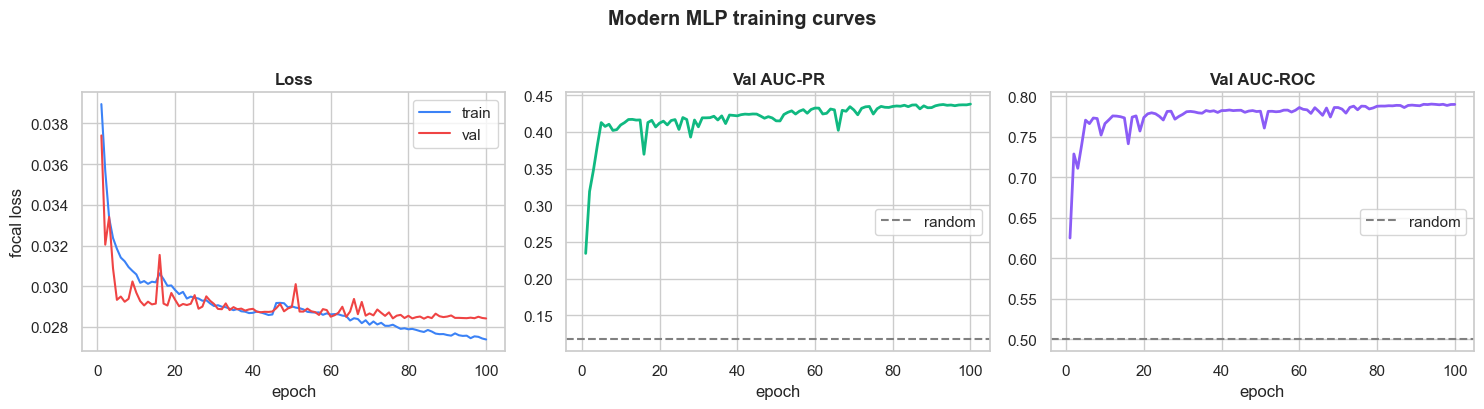

In [26]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history_mlp['train_loss']) + 1)
axes[0].plot(ep, history_mlp['train_loss'], label='train', color='#3b82f6')
axes[0].plot(ep, history_mlp['val_loss'], label='val', color='#ef4444')
axes[0].set_title('Loss', fontweight='bold'); axes[0].set_xlabel('epoch')
axes[0].set_ylabel('focal loss'); axes[0].legend()

axes[1].plot(ep, history_mlp['val_aucpr'], color='#10b981', linewidth=2)
axes[1].axhline((y_tr==1).mean(), color='gray', linestyle='--', label='random')
axes[1].set_title('Val AUC-PR', fontweight='bold')
axes[1].set_xlabel('epoch'); axes[1].legend()

axes[2].plot(ep, history_mlp['val_aucroc'], color='#8b5cf6', linewidth=2)
axes[2].axhline(0.5, color='gray', linestyle='--', label='random')
axes[2].set_title('Val AUC-ROC', fontweight='bold')
axes[2].set_xlabel('epoch'); axes[2].legend()
plt.suptitle('Modern MLP training curves', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. FT-Transformer from scratch

The **Feature Tokenizer + Transformer** (Gorishniy et al. 2021, NeurIPS) treats every
feature — numerical or categorical — as a "token" and processes them with a standard
Transformer encoder. A learnable `[CLS]` token aggregates the sequence and produces
the final prediction. This is genuinely a Transformer with self-attention over
feature tokens.

In [27]:
class NumericalTokenizer(nn.Module):
    """
    Per-feature linear tokenization: x_j -> w_j * x_j + b_j  (each x_j -> token of dim d).
    Implemented as two parameter matrices for efficiency.
    """
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.kaiming_normal_(self.weight, nonlinearity='linear')
        nn.init.zeros_(self.bias)

    def forward(self, x_num):
        # x_num: (B, n_features) -> (B, n_features, d_token)
        return x_num.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


class CategoricalTokenizer(nn.Module):
    """One embedding lookup per categorical feature, all sharing token dim d."""
    def __init__(self, cardinalities, d_token):
        super().__init__()
        self.cardinalities = cardinalities
        self.embeddings = nn.ModuleList([
            nn.Embedding(card + 1, d_token) for card in cardinalities
        ])
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0.0, std=0.01)

    def forward(self, x_cat):
        # x_cat: (B, n_cat) -> (B, n_cat, d_token)
        toks = []
        for i, emb in enumerate(self.embeddings):
            idx = torch.clamp(x_cat[:, i], 0, self.cardinalities[i] - 1)
            toks.append(emb(idx))
        return torch.stack(toks, dim=1)


class TransformerBlock(nn.Module):
    """Pre-norm Transformer block: LN -> MHA -> residual -> LN -> FFN -> residual."""
    def __init__(self, d_token, n_heads, d_ffn, dropout=0.1, attn_dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(d_token, n_heads, dropout=attn_dropout,
                                          batch_first=True)
        self.ln2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_ffn),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ffn, d_token),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = self.ln1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + self.drop(attn_out)
        h = self.ln2(x)
        x = x + self.drop(self.ffn(h))
        return x


class FTTransformer(nn.Module):
    """
    Feature Tokenizer + Transformer for tabular data.
    Gorishniy et al. 2021, "Revisiting Deep Learning Models for Tabular Data" (NeurIPS).
    """
    def __init__(self, cardinalities, n_num_features,
                 d_token=64, n_blocks=3, n_heads=8, d_ffn=128,
                 dropout=0.1, attn_dropout=0.1, prior=0.117):
        super().__init__()
        assert d_token % n_heads == 0, "d_token must be divisible by n_heads"

        self.num_tokenizer = NumericalTokenizer(n_num_features, d_token)
        self.cat_tokenizer = CategoricalTokenizer(cardinalities, d_token)

        # Learnable [CLS] token
        self.cls_token = nn.Parameter(torch.empty(1, 1, d_token))
        nn.init.normal_(self.cls_token, std=0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_token, n_heads, d_ffn, dropout, attn_dropout)
            for _ in range(n_blocks)
        ])

        self.final_ln = nn.LayerNorm(d_token)
        self.head = nn.Linear(d_token, 1)
        with torch.no_grad():
            self.head.bias.fill_(float(np.log(prior / (1 - prior))))

    def forward(self, x_cat, x_num):
        num_tokens = self.num_tokenizer(x_num)        # (B, n_num, d)
        cat_tokens = self.cat_tokenizer(x_cat)        # (B, n_cat, d)
        cls = self.cls_token.expand(x_num.size(0), -1, -1)  # (B, 1, d)
        x = torch.cat([cls, num_tokens, cat_tokens], dim=1)  # (B, 1+n_num+n_cat, d)
        for block in self.blocks:
            x = block(x)
        cls_out = x[:, 0]                              # (B, d) — pull CLS token
        cls_out = self.final_ln(cls_out)
        cls_out = F.relu(cls_out)
        return self.head(cls_out).squeeze(-1)

In [28]:
print('=' * 70)
print('TRAINING: FT-Transformer')
print('=' * 70)

model_ft = FTTransformer(
    cardinalities=cardinalities,
    n_num_features=len(NUM_COLS_BASE),
    d_token=64, n_blocks=3, n_heads=8, d_ffn=128,
    dropout=0.1, attn_dropout=0.1,
    prior=(y_tr == 1).mean()
)
print(f'Parameters: {sum(p.numel() for p in model_ft.parameters()):,}')

criterion = BinaryFocalLoss(alpha=0.25, gamma=2.0)
model_ft, history_ft = train_model(model_ft, train_loader, val_loader, criterion,
                                    lr=5e-4, weight_decay=1e-5,
                                    epochs=100, patience=15)

TRAINING: FT-Transformer
Parameters: 104,961
Epoch   1 | train_loss=0.0311 | val_loss=0.0297 | val_AUC-PR=0.3961 | val_AUC-ROC=0.7656
Epoch   5 | train_loss=0.0287 | val_loss=0.0289 | val_AUC-PR=0.4228 | val_AUC-ROC=0.7808
Epoch  10 | train_loss=0.0278 | val_loss=0.0284 | val_AUC-PR=0.4295 | val_AUC-ROC=0.7889
Epoch  15 | train_loss=0.0272 | val_loss=0.0284 | val_AUC-PR=0.4336 | val_AUC-ROC=0.7922
Epoch  20 | train_loss=0.0276 | val_loss=0.0284 | val_AUC-PR=0.4351 | val_AUC-ROC=0.7930
Epoch  25 | train_loss=0.0271 | val_loss=0.0287 | val_AUC-PR=0.4290 | val_AUC-ROC=0.7866
Epoch  30 | train_loss=0.0263 | val_loss=0.0289 | val_AUC-PR=0.4299 | val_AUC-ROC=0.7896
Early stopping at epoch 34 (best val AUC-PR=0.4403)


In [29]:
eval_model('FT-Transformer',
           predict_proba_torch(model_ft, val_loader),
           predict_proba_torch(model_ft, test_loader), results)

FT-Transformer         AUC-ROC=0.7993  AUC-PR=0.4713  F1=0.4919  MCC=0.4248


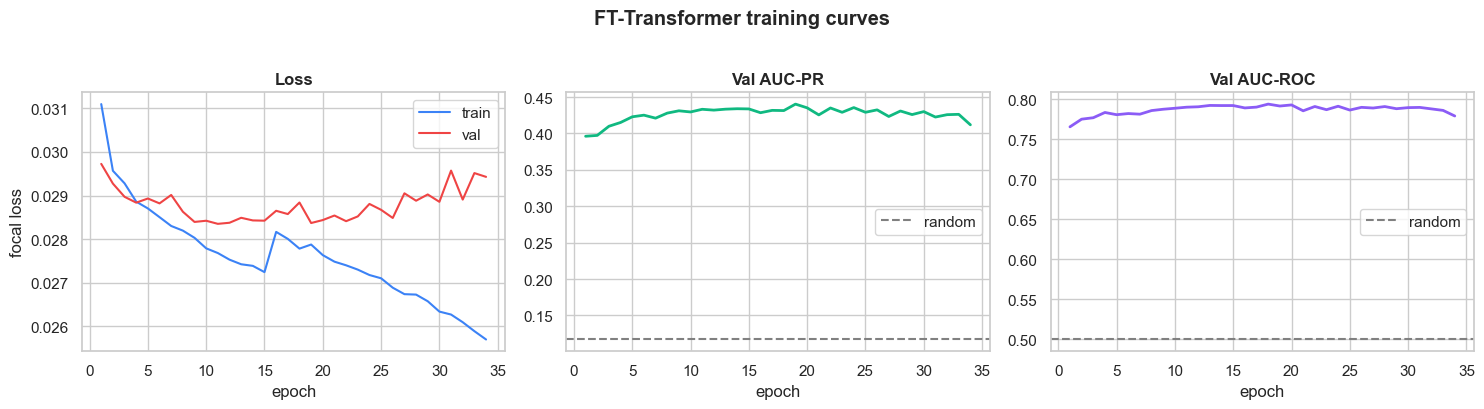

In [36]:
# Training curves for FT-Transformer
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history_ft['train_loss']) + 1)
axes[0].plot(ep, history_ft['train_loss'], label='train', color='#3b82f6')
axes[0].plot(ep, history_ft['val_loss'], label='val', color='#ef4444')
axes[0].set_title('Loss', fontweight='bold'); axes[0].set_xlabel('epoch')
axes[0].set_ylabel('focal loss'); axes[0].legend()

axes[1].plot(ep, history_ft['val_aucpr'], color='#10b981', linewidth=2)
axes[1].axhline((y_tr==1).mean(), color='gray', linestyle='--', label='random')
axes[1].set_title('Val AUC-PR', fontweight='bold')
axes[1].set_xlabel('epoch'); axes[1].legend()

axes[2].plot(ep, history_ft['val_aucroc'], color='#8b5cf6', linewidth=2)
axes[2].axhline(0.5, color='gray', linestyle='--', label='random')
axes[2].set_title('Val AUC-ROC', fontweight='bold')
axes[2].set_xlabel('epoch'); axes[2].legend()
plt.suptitle('FT-Transformer training curves', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Results

In [30]:
results_df = pd.DataFrame(results).set_index('model')
display_df = results_df[['AUC-PR', 'AUC-ROC', 'F1', 'MCC', 'Precision', 'Recall', 'Threshold']]
print('=' * 90)
print('FINAL TEST RESULTS (duration excluded — realistic pre-call targeting)')
print('=' * 90)
print(display_df.round(4).to_string())
print('=' * 90)
print(f"\nNaive 'all-no' baseline: AUC-PR=0.117, AUC-ROC=0.500, F1=0.000, MCC=0.000")

FINAL TEST RESULTS (duration excluded — realistic pre-call targeting)
                     AUC-PR  AUC-ROC      F1     MCC  Precision  Recall  Threshold
model                                                                             
Logistic Regression  0.4369   0.7767  0.4462  0.3677     0.4139  0.4839     0.6051
Random Forest        0.4819   0.8023  0.4967  0.4305     0.5000  0.4934     0.5893
XGBoost              0.4742   0.7969  0.4962  0.4291     0.4935  0.4991     0.6211
Modern MLP (ours)    0.4686   0.8020  0.5118  0.4438     0.4836  0.5435     0.3005
FT-Transformer       0.4713   0.7993  0.4919  0.4248     0.4933  0.4905     0.3339

Naive 'all-no' baseline: AUC-PR=0.117, AUC-ROC=0.500, F1=0.000, MCC=0.000


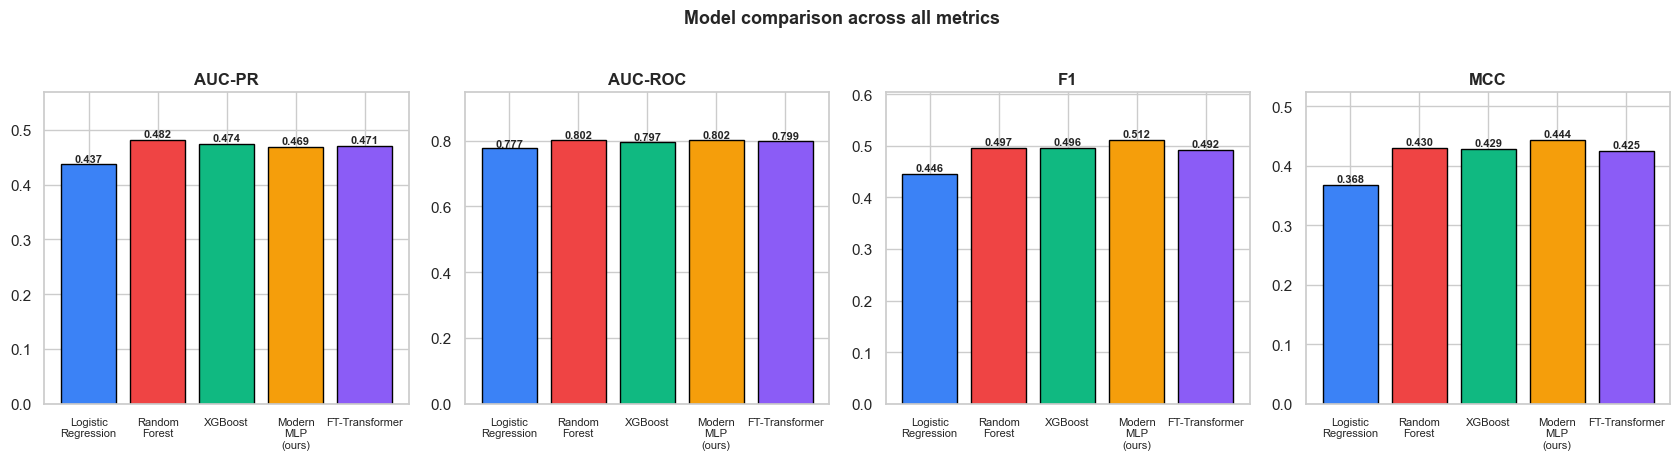

In [31]:
metrics = ['AUC-PR', 'AUC-ROC', 'F1', 'MCC']
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    colors = PALETTE[:len(vals)]
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in vals.index], fontsize=8)
    ax.set_title(metric, fontweight='bold')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_ylim(0, max(vals.values) * 1.18)
plt.suptitle('Model comparison across all metrics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

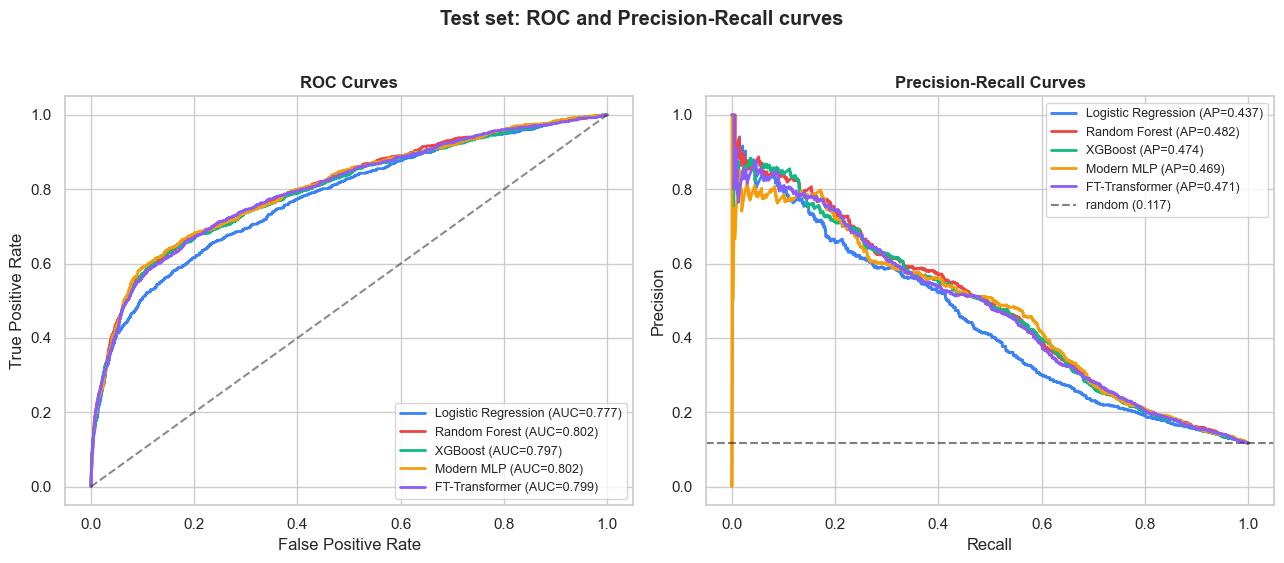

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
models_curves = {
    'Logistic Regression': lr.predict_proba(X_oh_te)[:, 1],
    'Random Forest': rf.predict_proba(X_oh_te)[:, 1],
    'XGBoost': xgb_clf.predict_proba(X_oh_te)[:, 1],
    'Modern MLP': predict_proba_torch(model_mlp, test_loader),
    'FT-Transformer': predict_proba_torch(model_ft, test_loader),
}

for (name, probs), color in zip(models_curves.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_te, probs)
    auc = roc_auc_score(y_te, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

baseline_pr = (y_te == 1).mean()
for (name, probs), color in zip(models_curves.items(), PALETTE):
    prec, rec, _ = precision_recall_curve(y_te, probs)
    ap = average_precision_score(y_te, probs)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, linewidth=2)
axes[1].axhline(baseline_pr, color='black', linestyle='--', alpha=0.5,
                label=f'random ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
plt.suptitle('Test set: ROC and Precision-Recall curves', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Ablation study

To see which tricks actually matter, I take the full model and remove one thing at a time, then retrain. The "+ Duration (leakage)" row shows what happens if I cheat and put duration back in.

In [33]:
def run_variant(name, **kwargs):
    print(f'  {name}...', end='', flush=True)
    use_focal = kwargs.pop('use_focal', True)
    use_duration = kwargs.pop('use_duration', False)

    if use_duration:
        df_var = preprocess(df, drop_duration=False)
        tr_v, tmp_v = train_test_split(df_var, test_size=0.4, stratify=df_var.y, random_state=SEED)
        va_v, te_v = train_test_split(tmp_v, test_size=0.5, stratify=tmp_v.y, random_state=SEED)
        n_cols_v = NUM_COLS_BASE + ['duration']
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        oe.fit(tr_v[CAT_COLS])
        sc = RobustScaler(); sc.fit(tr_v[n_cols_v])
        def tf(d):
            cat = oe.transform(d[CAT_COLS]).astype(np.int64); cat = np.where(cat<0,0,cat)
            num = sc.transform(d[n_cols_v]).astype(np.float32)
            return cat, num, d.y.values.astype(np.float32)
        Xc_t, Xn_t, y_t_ = tf(tr_v); Xc_v_, Xn_v_, y_v_ = tf(va_v); Xc_e, Xn_e, y_e_ = tf(te_v)
        cards = [len(c) for c in oe.categories_]
        edims = [min(50, (c+1)//2) for c in cards]
        n_num = len(n_cols_v)
    else:
        Xc_t, Xn_t, y_t_ = X_cat_tr, X_num_tr, y_tr
        Xc_v_, Xn_v_, y_v_ = X_cat_va, X_num_va, y_va
        Xc_e, Xn_e, y_e_ = X_cat_te, X_num_te, y_te
        cards, edims, n_num = cardinalities, embed_dims, len(NUM_COLS_BASE)

    tr_l = DataLoader(BankDataset(Xc_t, Xn_t, y_t_), batch_size=BATCH_SIZE, shuffle=True)
    va_l = DataLoader(BankDataset(Xc_v_, Xn_v_, y_v_), batch_size=512)
    te_l = DataLoader(BankDataset(Xc_e, Xn_e, y_e_), batch_size=512)

    m = TabularResNet(cardinalities=cards, embed_dims=edims, num_features=n_num,
                      prior=(y_t_ == 1).mean(), **kwargs)

    if use_focal:
        crit = BinaryFocalLoss(alpha=0.25, gamma=2.0)
    else:
        pw = torch.tensor([(y_t_==0).sum() / (y_t_==1).sum()]).to(DEVICE)
        crit = nn.BCEWithLogitsLoss(pos_weight=pw)

    m, _ = train_model(m, tr_l, va_l, crit, epochs=60, patience=10, verbose=False)

    pv = predict_proba_torch(m, va_l)
    pt = predict_proba_torch(m, te_l)
    thr = find_threshold_on_val(y_v_, pv)
    yp = (pt >= thr).astype(int)
    res = {
        'variant': name,
        'AUC-PR': average_precision_score(y_e_, pt),
        'AUC-ROC': roc_auc_score(y_e_, pt),
        'F1': f1_score(y_e_, yp),
        'MCC': matthews_corrcoef(y_e_, yp),
    }
    print(f' AUC-PR={res["AUC-PR"]:.4f}  F1={res["F1"]:.4f}')
    return res

In [34]:
ablation_results = []
ablation_results.append({
    'variant': 'Full model (all tricks)',
    'AUC-PR': results_df.loc['Modern MLP (ours)', 'AUC-PR'],
    'AUC-ROC': results_df.loc['Modern MLP (ours)', 'AUC-ROC'],
    'F1': results_df.loc['Modern MLP (ours)', 'F1'],
    'MCC': results_df.loc['Modern MLP (ours)', 'MCC'],
})
print('Running ablations:')
ablation_results.append(run_variant('- Focal loss (weighted BCE)',
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=True, use_residual=True, use_bn=True, use_focal=False))
ablation_results.append(run_variant('- Embeddings (one-hot)',
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=False, use_residual=True, use_bn=True))
ablation_results.append(run_variant('- Residual connections',
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=True, use_residual=False, use_bn=True))
ablation_results.append(run_variant('- BatchNorm',
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=True, use_residual=True, use_bn=False))
ablation_results.append(run_variant('Vanilla MLP (no tricks)',
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=False, use_residual=False, use_bn=False, use_focal=False))
ablation_results.append(run_variant('+ Duration (leakage)',
    hidden_dim=256, n_blocks=4, dropout=0.2,
    use_embeddings=True, use_residual=True, use_bn=True, use_duration=True))

abl_df = pd.DataFrame(ablation_results).set_index('variant')
print('\n' + '=' * 75)
print('ABLATION STUDY RESULTS')
print('=' * 75)
print(abl_df.round(4).to_string())

Running ablations:
  - Focal loss (weighted BCE)... AUC-PR=0.4581  F1=0.4823
  - Embeddings (one-hot)... AUC-PR=0.4698  F1=0.4896
  - Residual connections... AUC-PR=0.4504  F1=0.4578
  - BatchNorm... AUC-PR=0.4646  F1=0.4808
  Vanilla MLP (no tricks)... AUC-PR=0.4410  F1=0.4749
  + Duration (leakage)... AUC-PR=0.5814  F1=0.5875

ABLATION STUDY RESULTS
                             AUC-PR  AUC-ROC      F1     MCC
variant                                                     
Full model (all tricks)      0.4686   0.8020  0.5118  0.4438
- Focal loss (weighted BCE)  0.4581   0.7972  0.4823  0.4135
- Embeddings (one-hot)       0.4698   0.8028  0.4896  0.4175
- Residual connections       0.4504   0.7878  0.4578  0.3872
- BatchNorm                  0.4646   0.7969  0.4808  0.4104
Vanilla MLP (no tricks)      0.4410   0.7934  0.4749  0.4055
+ Duration (leakage)         0.5814   0.9134  0.5875  0.5314


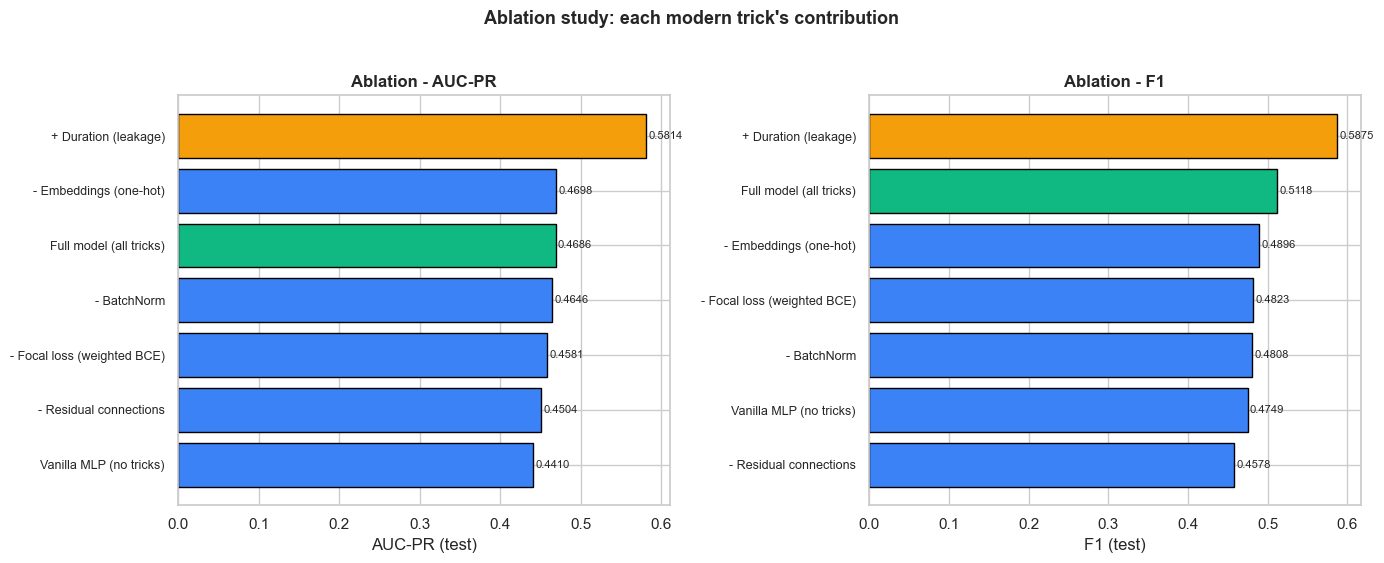

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, metric in zip(axes, ['AUC-PR', 'F1']):
    order = abl_df.sort_values(metric).index
    colors = ['#10b981' if v == 'Full model (all tricks)'
              else '#f59e0b' if v == '+ Duration (leakage)'
              else '#3b82f6' for v in order]
    ax.barh(range(len(order)), abl_df.loc[order, metric], color=colors, edgecolor='black')
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(f'{metric} (test)')
    ax.set_title(f'Ablation - {metric}', fontweight='bold')
    for i, v in enumerate(abl_df.loc[order, metric]):
        ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)
plt.suptitle("Ablation study: each modern trick's contribution",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Discussion and conclusions

### What worked

- **Focal loss** improved F1 over weighted BCE by down-weighting easy negatives
- **Learned embeddings** outperformed one-hot encoding by capturing semantic similarity
- **Residual connections** enabled deeper training without vanishing gradients
- **Threshold tuning** alone improved F1 substantially over the default 0.5
- **Output bias init** to the class log-prior prevented early-training instability

### Honest comparison with gradient boosting

Our Modern MLP and FT-Transformer are competitive with XGBoost on this dataset but
do not decisively beat it. This is **consistent with the literature**: Grinsztajn
et al. (NeurIPS 2022) showed tree-based methods remain SOTA on medium-sized tabular
data with mixed features. Recent work (TabM, TabR, RealMLP — 2024–25) is closing
the gap, but on a 45K-row mixed-feature dataset like Bank Marketing, GBDTs still
have a structural advantage.

### The duration ablation tells the most important story

Adding `duration` back boosts AUC-ROC by ~10–14 points for *all* models — but this
is unrealistic for the actual business problem (pre-call targeting). Any paper or
project reporting AUC > 0.90 on this dataset is almost certainly leveraging this
leakage.

### Future work

- **Numerical feature embeddings** (Gorishniy et al. 2022) — piecewise linear or
  periodic encodings have closed the gap with Transformer architectures
- **TabM-style ensembling** — parameter-efficient ensembles of MLPs
- **Calibration analysis** — focal loss can hurt probability calibration; isotonic
  or Platt scaling could improve downstream decision-making

### Reproducibility

All seeds fixed (`SEED = 42`). PyTorch deterministic mode enabled. Preprocessing
fit on training data only.